In [4]:
import sys
import glob
import torch

sys.path.append('../utils/')
sys.path.append('../src/model/')

import DistanceMemoryModel
import encoders

sys.path.append('/om2/user/bjmedina/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params

In [5]:
# grabbing example list of sound
sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_p1/*wav")
texture_list = sounds_list

ALL_SOUNDS = glob.glob("/om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_*/*wav")
print(len(ALL_SOUNDS))

2008997


# running encoders

In [6]:
texture_model = encoders.AudioTextureEncoder(
    statistics_dict=statistics_dict,
    model_params=model_params,
    sr=20000,
    rms_level=0.05,
    duration=2.0,
    device='cuda'
)

In [7]:
projector = encoders.PCASpace(texture_model, n_components=None)  # or use encoder output dim explicitly
projector.fit(texture_list)

dim = (projector.pca.explained_variance_ratio_.cumsum() > 0.9).tolist().index(True)

In [8]:
projector = encoders.PCASpace(texture_model, n_components=dim)

# Fit on example_trials
projector.fit(texture_list)

# Project those same trials or new ones
coords = projector.transform(texture_list)

In [10]:
zscore_projector = encoders.ZScoreSpace(texture_model)
zscore_projector.fit(texture_list)

In [11]:
# for the 'encoding_model' -- any encoder would do.
# in this case, AudioTextureEncoder is the auditory texture model. that works fine
# 

memory_model = DistanceMemoryModel.DistanceMemoryModel(
    encoding_model=zscore_projector,
    noise_variance=0.1,
    criterion=10,
    device='cuda'
)

memory_model.clear_memory()

example_trials = [sounds_list[0],
                  sounds_list[1],
                  sounds_list[2],
                  sounds_list[3],
                  sounds_list[0],
                  sounds_list[1]]

for j, path in enumerate(example_trials):
    decision = memory_model(path)
    true_answer = 'YES' if example_trials[j] in example_trials[:j] else 'NO'
    print(f"{path.split('/')[-1]} ==> Model {'YES' if decision.item() else 'NO'}, True {true_answer}")

mem_stim_34.wav ==> Model NO, True NO
mem_stim_136.wav ==> Model NO, True NO
mem_stim_99.wav ==> Model NO, True NO
mem_stim_48.wav ==> Model NO, True NO
mem_stim_34.wav ==> Model YES, True YES
mem_stim_136.wav ==> Model YES, True YES


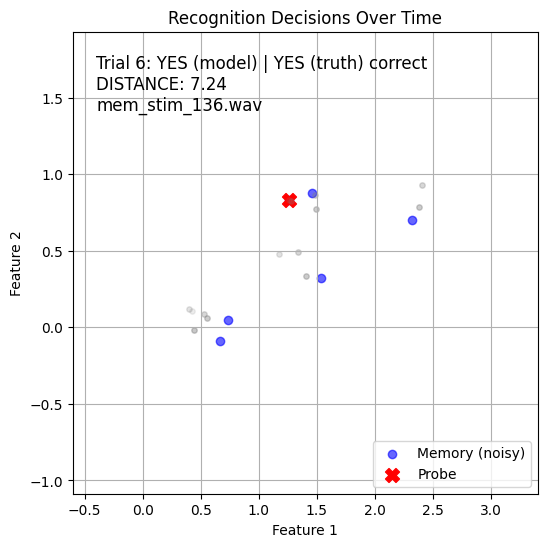

In [12]:
memory_model.animate_trials()

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

probe_reps = []
memory_snapshots = []
decisions = []

memory_model.clear_memory()

example_trials = [sounds_list[0],
                  sounds_list[1],
                  sounds_list[2],
                  sounds_list[3],
                  sounds_list[0],
                  sounds_list[1],
                  sounds_list[4],
                  sounds_list[5],
                  sounds_list[6],
                  sounds_list[7],
                  sounds_list[3],
                 ]

for j, path in enumerate(example_trials):
    current_rep = memory_model.encode_sound(path).detach().cpu()
    memory_snapshot = torch.stack(memory_model.memory_bank).detach().cpu() if memory_model.memory_bank else torch.empty(0, current_rep.shape[0])
    
    decision = memory_model(path)
    true_answer = 'YES' if example_trials[j] in example_trials[:j] else 'NO'


    decisions.append(decision.item())


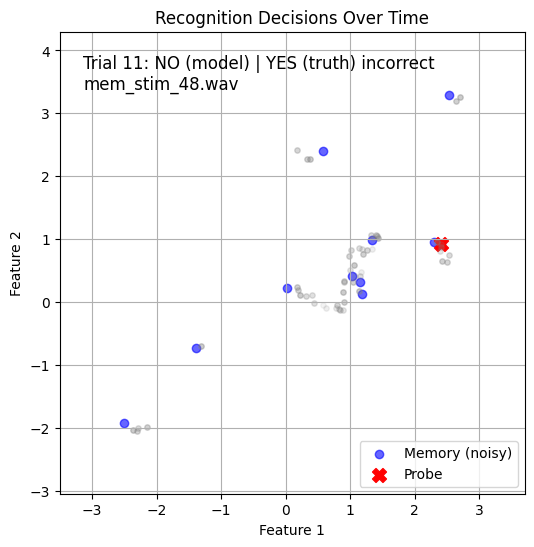

In [26]:
memory_model.animate_trials()